# Algorithms for massive data Project

## Data loading

In [5]:
import os
import zipfile
os.environ['KAGGLE_USERNAME'] = "xxxx"
os.environ['KAGGLE_KEY'] = "xxxx"
!kaggle datasets download -d Cornell-University/arxiv
with zipfile.ZipFile("arxiv.zip", "r") as zip_ref:
    zip_ref.extractall("arxiv_data")

('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0




  0%|          | 0.00/1.64G [00:00<?, ?B/s]
  0%|          | 1.00M/1.64G [00:00<18:53, 1.55MB/s]
  0%|          | 2.00M/1.64G [00:01<13:10, 2.23MB/s]
  0%|          | 3.00M/1.64G [00:01<10:39, 2.75MB/s]
  0%|          | 4.00M/1.64G [00:01<09:00, 3.25MB/s]
  0%|          | 5.00M/1.64G [00:01<08:45, 3.35MB/s]
  0%|          | 6.00M/1.64G [00:02<08:21, 3.50MB/s]
  0%|          | 7.00M/1.64G [00:02<07:48, 3.74MB/s]
  0%|          | 8.00M/1.64G [00:02<07:29, 3.90MB/s]
  1%|          | 9.00M/1.64G [00:02<07:11, 4.06MB/s]
  1%|          | 10.0M/1.64G [00:03<07:09, 4.08MB/s]
  1%|          | 11.0M/1.64G [00:03<07:36, 3.83MB/s]
  1%|          | 12.0M/1.64G [00:03<06:59, 4.17MB/s]
  1%|          | 13.0M/1.64G [00:03<06:27, 4.51MB/s]
  1%|          | 14.0M/1.64G [00:03<05:44, 5.07MB/s]
  1%|          | 16.0M/1.64G [00:04<04:08, 7.01MB/s]
  1%|          | 17.0M/1.64G [00:04<04:14, 6.85MB/s]
  1%|          | 19.0M/1.64G [00:04<03:25, 8.48MB/s]
  1%|          | 20.0M/1.64G [00:04<03:30, 8.28MB/s]
 

## Configuration

In [6]:
import json
DATA_FILE = "arxiv_data/arxiv-metadata-oai-snapshot.json"
MAX_RECORDS = 1000000
MIN_PAPERS  = 2
DAMPING = 0.85
TOP_N = 20

## Parsing author names

In [7]:
def get_authors(record):
    parsed = record.get("authors_parsed") or []
    if parsed:
        names = []
        for entry in parsed:
            last = entry[0].strip() if len(entry) > 0 else ""
            first = entry[1].strip() if len(entry) > 1 else ""
            if last:
                names.append(f"{last}, {first}" if first else last)
        return names

    return [a.strip() for a in record.get("authors", "").split(",") if a.strip()]

## Authors count

In [8]:
paper_count = {}
n = 0

with zipfile.ZipFile("arxiv.zip", 'r') as z:
    with z.open("arxiv-metadata-oai-snapshot.json") as f:
        for line in f:
            if n >= MAX_RECORDS:
                break
            record = json.loads(line)
            for author in get_authors(record):
                paper_count[author] = paper_count.get(author, 0) + 1
            n += 1
eligible_authors = {author for author, count in paper_count.items() if count >= MIN_PAPERS}
print(f"Total unique authors: {len(paper_count):,}")
print(f"Eligible authors (written >= {MIN_PAPERS} papers): {len(eligible_authors):,}")

Total unique authors: 774,393
Eligible authors (written >= 2 papers): 405,602


## Co-authorship graph

In [10]:
!pip install igraph
import gc
import igraph as ig
from collections import defaultdict
import itertools

edge_weights = defaultdict(int)
n = 0

authors_list = sorted(list(eligible_authors))
author_to_id = {author: idx for idx, author in enumerate(authors_list)}

with zipfile.ZipFile("arxiv.zip", 'r') as z:
    with z.open("arxiv-metadata-oai-snapshot.json") as f:
        for line in f:
            if n >= MAX_RECORDS:
                break
            record = json.loads(line)
            authors = [a for a in get_authors(record) if a in eligible_authors]

            author_ids = sorted([author_to_id[a] for a in authors])
            
            for u, v in itertools.combinations(author_ids, 2):
                edge_weights[(u, v)] += 1
            
            n += 1

edges = list(edge_weights.keys())
weights = list(edge_weights.values())

del edge_weights
gc.collect()

G_ig = ig.Graph(n=len(authors_list), edges=edges, directed=False)
G_ig.es["weight"] = weights

print(f"Graph created with {G_ig.vcount():,} nodes and {G_ig.ecount():,} edges.")

ERROR: Could not find a version that satisfies the requirement gc (from versions: none)
ERROR: No matching distribution found for gc


Graph created with 405,602 nodes and 24,460,396 edges.


## PageRank computation

In [11]:
!pip install pandas
!pip install scipy
import scipy as sp
import pandas as pd

pr_unweighted = G_ig.pagerank(weights=None, damping=DAMPING)
pr_weighted   = G_ig.pagerank(weights="weight", damping=DAMPING)

# clean pandas df
df = pd.DataFrame({
    "author": authors_list,
    "papers": [paper_count.get(node, 0) for node in authors_list],
    "degree": G_ig.degree(),
    "pr_unweighted": pr_unweighted,
    "pr_weighted": pr_weighted,
})

del paper_count
gc.collect()

print(f"\n Top {TOP_N} by PageRank")
top_weighted = df.nlargest(TOP_N, "pr_weighted")
print(top_weighted[["author", "papers", "degree", "pr_weighted"]].to_string(index=False))


 Top 20 by PageRank
              author  papers  degree  pr_weighted
           Zhang, Y.    1162   10368     0.000129
  Taniguchi, Takashi     289    1010     0.000126
     Watanabe, Kenji     269     963     0.000121
      Guo, Guang-Can     378     414     0.000101
            Chen, Xi     351     766     0.000095
    Poor, H. Vincent     376     362     0.000091
          Zhang, Wei     356     760     0.000091
Schneider, Donald P.     361    2089     0.000090
           Wang, Wei     400    1131     0.000089
           Chen, Wei     374     703     0.000089
              Li, Y.     802    9346     0.000089
            Wang, Y.     573    8953     0.000088
             Li, Wei     296     773     0.000085
          Wang, Jian     327     646     0.000084
           Zhang, L.     800   10926     0.000084
           Liu, Yang     301     657     0.000083
        Nori, Franco     401     449     0.000079
          Zhang, Jun     340     609     0.000078
              Li, X.     426 

## Plot

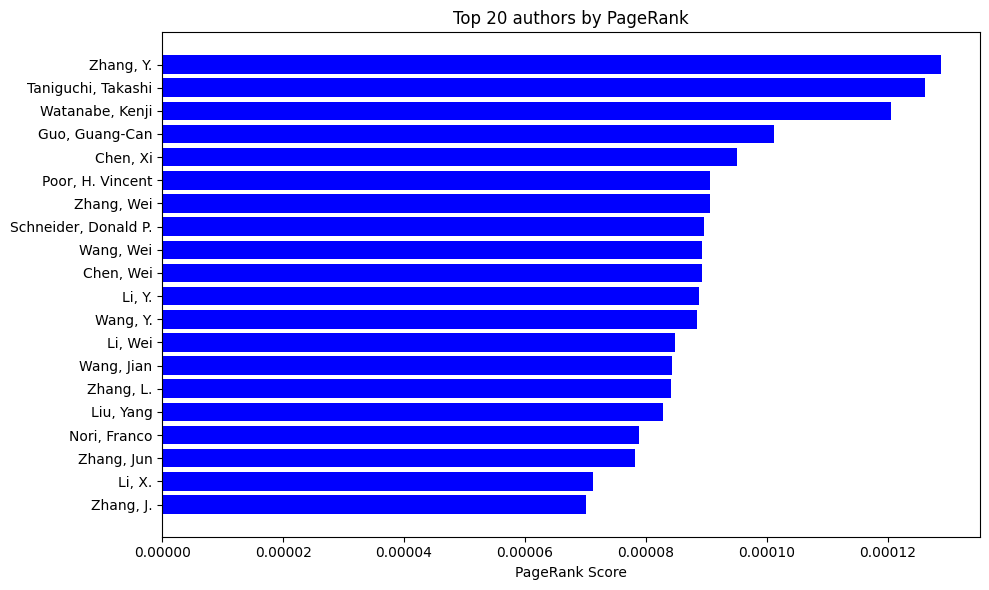

In [12]:
!pip install matplotlib
import matplotlib.pyplot as plt

top_chart_data = top_weighted.sort_values("pr_weighted", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top_chart_data["author"], top_chart_data["pr_weighted"], color='blue')
plt.xlabel("PageRank Score")
plt.title(f"Top {TOP_N} authors by PageRank")
plt.tight_layout()
plt.show()